In [6]:
import pandas as pd
import numpy as np

In [7]:
df_clean = pd.read_csv("data_no_outliers.csv")

In [8]:
features = [
    'Depth (ft)',
    'Weight on bit (k-lbs)',
    'Temperature Out (deg F)',
    'Temperature In(deg F)',
    'Pit Total (bbls)',
    'Pump Pressure (psi)',
    'Hook load (k-lbs)',
    'Surface Torque (psi)',
    'Rotary Speed (rpm)',
    'Flow In (gal/min)',
    'Flow Out Percentage (%)'
]

target = 'ROP (ft/hr)'

X = df_clean[features]
y = df_clean[target]

In [9]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Train Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [11]:
y_pred_rf = rf.predict(X_test)

In [12]:
# Evaluate
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² =", r2_rf)
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)

Random Forest Results
R² = 0.8402247815766979
MAE = 3.9700878298135955
RMSE = 6.834643274088555


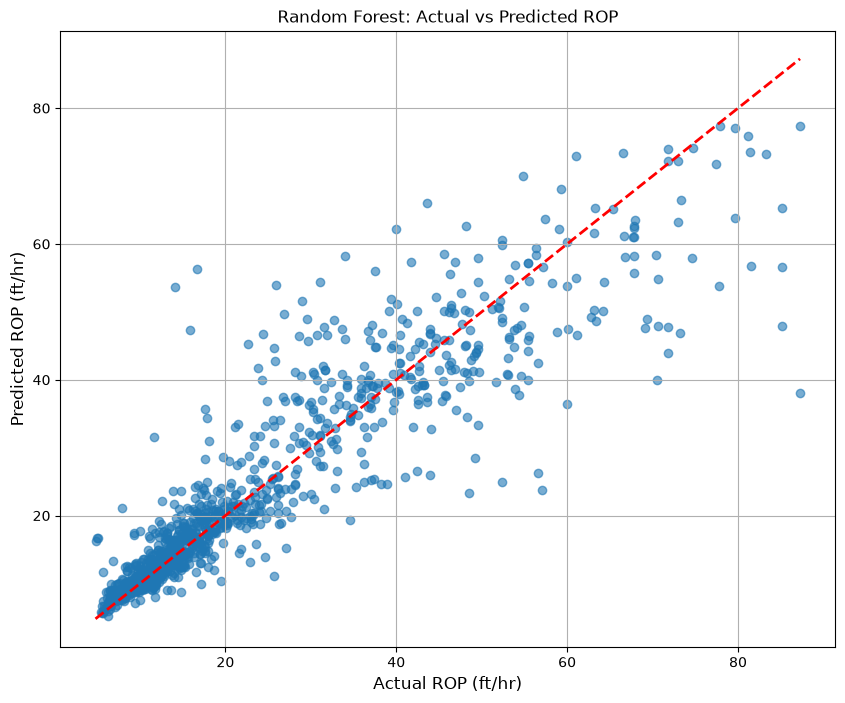

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual ROP (ft/hr)", fontsize=12)
plt.ylabel("Predicted ROP (ft/hr)", fontsize=12)
plt.title("Random Forest: Actual vs Predicted ROP")

plt.grid(True)
plt.show()

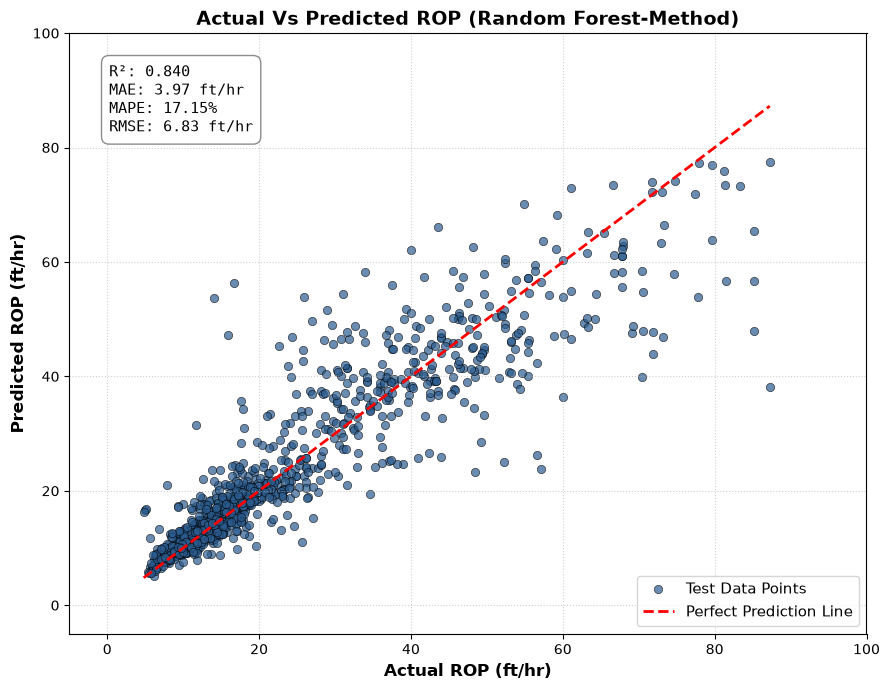

In [16]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape = np.mean(np.abs((y_test - y_pred_rf) / (y_test + 1e-10))) * 100

# 2. Plot setup
plt.figure(figsize=(9, 7))  # Made slightly more square for a balanced zoom view
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='#2b5c8f', edgecolors='k', linewidth=0.5, label="Test Data Points")

plt.xlabel('Actual ROP (ft/hr)', fontsize=12, weight='bold')
plt.ylabel('Predicted ROP (ft/hr)', fontsize=12, weight='bold')
plt.title('Actual Vs Predicted ROP (Random Forest-Method)', fontsize=14, weight='bold')

# 3. Diagonal reference line
min_val = min(min(y_test), min(y_pred_rf))
max_val = max(max(y_test), max(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction Line") 

# ==========================================
# ULTRA FOCUS AREA LIMITS (Zoomed into 0-150)
# ==========================================
plt.xlim(-5, 100)
plt.ylim(-5, 100)

# Add grid lines to make tracking individual points easier in tight space
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Create string text for metrics box
metrics_box = (
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f} ft/hr\n"
    f"MAPE: {mape:.2f}%\n"
    f"RMSE: {rmse:.2f} ft/hr"
)

# Position changed to 'upper left' but adjusted nicely for the tight window
box_properties = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.05, 0.95, metrics_box, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=box_properties, fontfamily='monospace')

# 5. Display indicators
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
0                Depth (ft)    0.718881
7      Surface Torque (psi)    0.074046
8        Rotary Speed (rpm)    0.034499
6         Hook load (k-lbs)    0.031601
2   Temperature Out (deg F)    0.029970
4          Pit Total (bbls)    0.023621
5       Pump Pressure (psi)    0.021647
3     Temperature In(deg F)    0.020656
9         Flow In (gal/min)    0.016620
1     Weight on bit (k-lbs)    0.015709
10  Flow Out Percentage (%)    0.012750


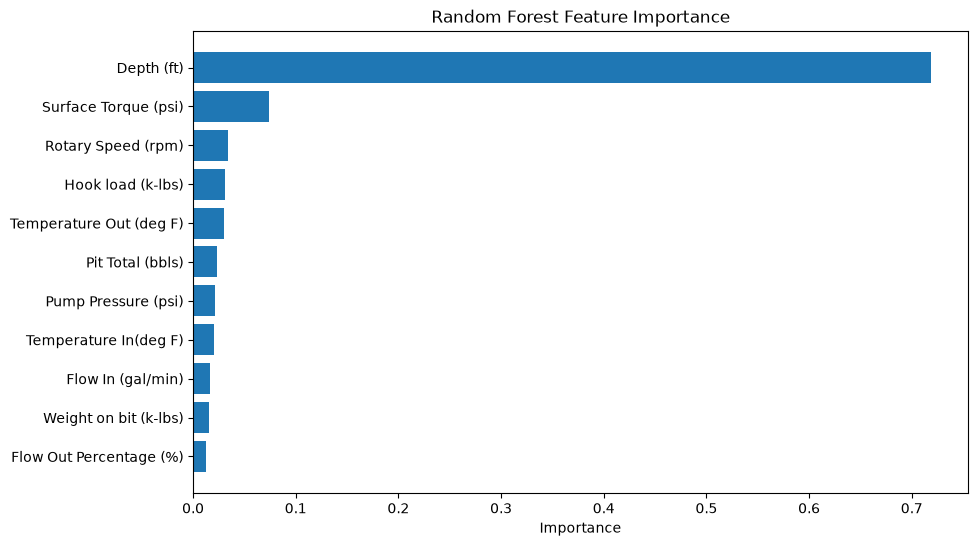

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

RANDOM FOREST RESULTS (WITHOUT DEPTH)
R²   : 0.8442
MAE  : 3.9600 ft/hr
RMSE : 6.7482 ft/hr
MAPE : 17.36%


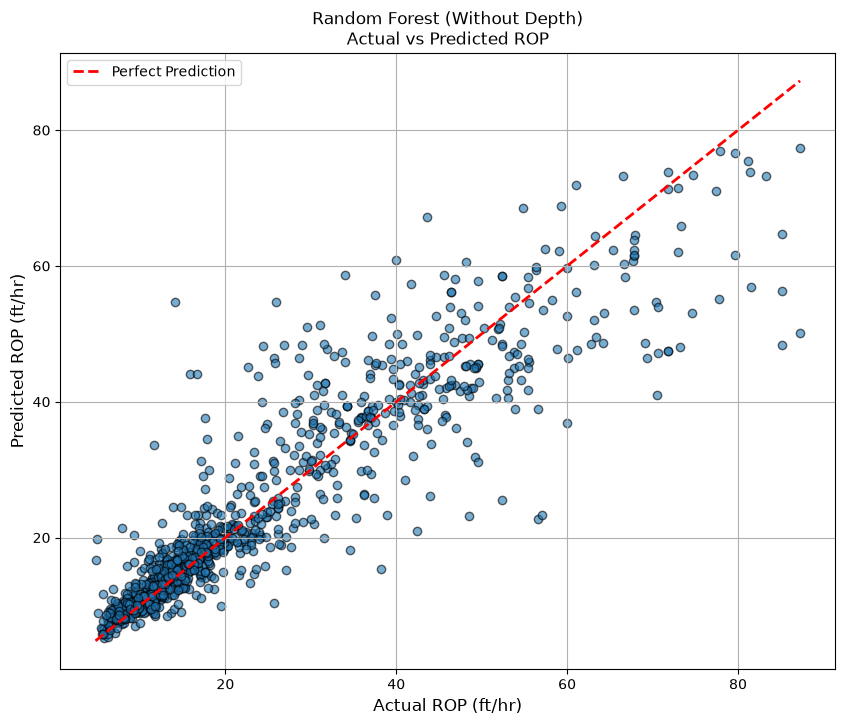


Feature Importance:
                   Feature  Importance
5        Hook load (k-lbs)    0.618436
2    Temperature In(deg F)    0.081302
1  Temperature Out (deg F)    0.075634
6     Surface Torque (psi)    0.067174
7       Rotary Speed (rpm)    0.037691
3         Pit Total (bbls)    0.032674
4      Pump Pressure (psi)    0.029063
8        Flow In (gal/min)    0.022129
0    Weight on bit (k-lbs)    0.018967
9  Flow Out Percentage (%)    0.016929


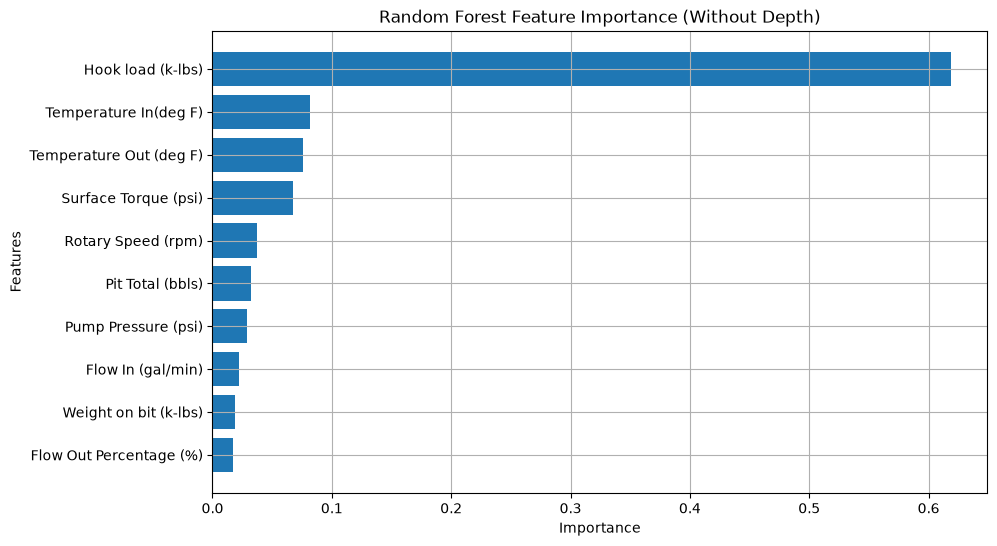

In [21]:
# Depth model is relying very heavily on Depth.

# This usually means one of two things:

# Case 1: Depth is genuinely the strongest predictor

# This is possible in geothermal drilling because:

# Rock properties change with depth.
# Temperature increases with depth.
# Drilling conditions evolve continuously.
# Case 2: Data leakage through depth

# If ROP changes smoothly with depth, the model may be using depth as a shortcut rather than learning the drilling mechanics. //


# =====================================================
# RANDOM FOREST ROP PREDICTION (WITHOUT DEPTH)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# =====================================================
# FEATURES & TARGET
# =====================================================

features = [
    'Weight on bit (k-lbs)',
    'Temperature Out (deg F)',
    'Temperature In(deg F)',
    'Pit Total (bbls)',
    'Pump Pressure (psi)',
    'Hook load (k-lbs)',
    'Surface Torque (psi)',
    'Rotary Speed (rpm)',
    'Flow In (gal/min)',
    'Flow Out Percentage (%)'
]

target = 'ROP (ft/hr)'

X = df_clean[features]
y = df_clean[target]

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# RANDOM FOREST MODEL
# =====================================================

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = rf.predict(X_test)

# =====================================================
# METRICS
# =====================================================

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print("="*50)
print("RANDOM FOREST RESULTS (WITHOUT DEPTH)")
print("="*50)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f} ft/hr")
print(f"RMSE : {rmse:.4f} ft/hr")
print(f"MAPE : {mape:.2f}%")

# =====================================================
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(10,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    edgecolors='black'
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual ROP (ft/hr)", fontsize=12)
plt.ylabel("Predicted ROP (ft/hr)", fontsize=12)
plt.title("Random Forest (Without Depth)\nActual vs Predicted ROP")

plt.legend()
plt.grid(True)

plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# =====================================================
# FEATURE IMPORTANCE PLOT
# =====================================================

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance (Without Depth)")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()